In [234]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

In [235]:
df = pd.read_csv("../dataset/startup_success_dataset.csv")

In [236]:
df.head()


,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,outcome
0,4,13,58,48.225483,594843,18.519211,1.483962e+06,tier2_vc,Health,academic,IPO
1,1,6,221,31.532647,393020,14.298149,8.620568e+05,tier2_vc,Fintech,first_time,Failure
2,3,5,247,4.969722,27636,20.447567,9.726169e+04,none,SaaS,first_time,Failure
3,3,14,229,3.084209,235376,8.177417,1.145785e+06,none,Ecommerce,ex_bigtech,Acquisition
4,1,17,235,13.818188,391765,4.879792,8.608949e+05,none,Health,first_time,Acquisition


In [237]:
df.shape


(100000, 11)

In [238]:
df.columns

Index(['funding_rounds', 'founder_experience_years', 'team_size',
       'market_size_billion', 'product_traction_users', 'burn_rate_million',
       'revenue_million', 'investor_type', 'sector', 'founder_background',
       'outcome'],
      dtype='object')

In [239]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   funding_rounds            100000 non-null  int64  
 1   founder_experience_years  100000 non-null  int64  
 2   team_size                 100000 non-null  int64  
 3   market_size_billion       100000 non-null  float64
 4   product_traction_users    100000 non-null  int64  
 5   burn_rate_million         100000 non-null  float64
 6   revenue_million           100000 non-null  float64
 7   investor_type             100000 non-null  object 
 8   sector                    100000 non-null  object 
 9   founder_background        100000 non-null  object 
 10  outcome                   100000 non-null  object 
dtypes: float64(3), int64(4), object(4)
memory usage: 8.4+ MB


In [240]:
df.describe()


,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05
mean,2.002300,12.024300,150.732000,33.203875,285422.832730,16.776213,7.828191e+05
std,1.414671,7.208089,86.272631,43.034753,159323.885405,15.711368,6.085069e+05
min,0.000000,0.000000,2.000000,0.288738,668.000000,0.279763,1.344810e+03
25%,1.000000,6.000000,76.000000,10.196778,161194.750000,7.087591,3.154861e+05
50%,2.000000,12.000000,151.000000,20.158063,264989.500000,12.169059,6.213624e+05
75%,3.000000,18.000000,226.000000,39.531967,389214.000000,20.953561,1.098921e+06
max,8.000000,24.000000,299.000000,1072.434476,915203.000000,357.491454,4.168443e+06


In [241]:
print(df.isnull().sum())

funding_rounds              0
founder_experience_years    0
team_size                   0
market_size_billion         0
product_traction_users      0
burn_rate_million           0
revenue_million             0
investor_type               0
sector                      0
founder_background          0
outcome                     0
dtype: int64


In [242]:
df["outcome"].value_counts()

outcome
Failure        55610
Acquisition    42335
IPO             2055
Name: count, dtype: int64

In [243]:
df.duplicated().sum()

np.int64(0)

In [244]:
print(df["sector"].unique())
print(df["founder_background"].unique())
print(df["outcome"].unique())

['Health' 'Fintech' 'SaaS' 'Ecommerce' 'Climate' 'Crypto' 'AI']
['academic' 'first_time' 'ex_bigtech' 'serial_founder']
['IPO' 'Failure' 'Acquisition']


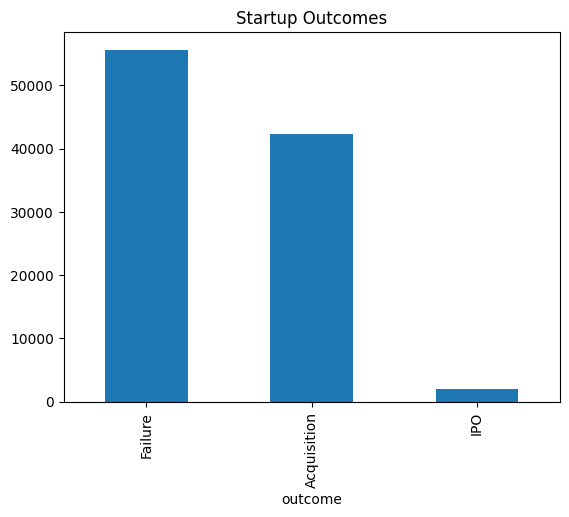

In [245]:
df["outcome"].value_counts().plot(kind="bar")

plt.title("Startup Outcomes")

plt.show()

In [246]:
df = df.drop(columns=["investor_type"])


In [247]:
df.head()

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,sector,founder_background,outcome
0,4,13,58,48.225483,594843,18.519211,1.483962e+06,Health,academic,IPO
1,1,6,221,31.532647,393020,14.298149,8.620568e+05,Fintech,first_time,Failure
2,3,5,247,4.969722,27636,20.447567,9.726169e+04,SaaS,first_time,Failure
3,3,14,229,3.084209,235376,8.177417,1.145785e+06,Ecommerce,ex_bigtech,Acquisition
4,1,17,235,13.818188,391765,4.879792,8.608949e+05,Health,first_time,Acquisition


In [248]:
df["outcome"] = df["outcome"].map({
    "Failure": 0,
    "Acquisition": 1,
    "IPO": 1
})
print(df["outcome"].value_counts())

outcome
0    55610
1    44390
Name: count, dtype: int64


In [249]:
X = df.drop("outcome", axis=1)
y = df["outcome"]

print(X.shape)
print(y.shape)

(100000, 9)
(100000,)


In [250]:
X.dtypes

funding_rounds                int64
founder_experience_years      int64
team_size                     int64
market_size_billion         float64
product_traction_users        int64
burn_rate_million           float64
revenue_million             float64
sector                       object
founder_background           object
dtype: object

In [251]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [252]:
categorical_features = [
    "sector","founder_background"
]

numerical_features = [
    "funding_rounds","founder_experience_years","team_size","market_size_billion","product_traction_users","burn_rate_million",
    "revenue_million"
]

In [253]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

rf_model = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,          
    ))
])

In [254]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [255]:
y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(X_test)[:, 1]

In [256]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.76015
Precision: 0.7563764291996482
Recall   : 0.6780806487947736
F1 Score : 0.7150917621904139
ROC AUC  : 0.835770764430088


In [257]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.83      0.79     11122
           1       0.76      0.68      0.72      8878

    accuracy                           0.76     20000
   macro avg       0.76      0.75      0.75     20000
weighted avg       0.76      0.76      0.76     20000

[[9183 1939]
 [2858 6020]]


In [258]:
scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print(scores)
print("Mean ROC-AUC:", scores.mean())

[0.83208381 0.83617104 0.83196614 0.83624621 0.83691784]
Mean ROC-AUC: 0.8346770093220336


In [259]:
import joblib

joblib.dump(rf_model, "funding_model.pkl")

['funding_model.pkl']

In [260]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importances = rf_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
17,remainder__revenue_million,0.323345
15,remainder__product_traction_users,0.215164
11,remainder__funding_rounds,0.107395
12,remainder__founder_experience_years,0.102599
13,remainder__team_size,0.073917
16,remainder__burn_rate_million,0.062206
14,remainder__market_size_billion,0.061945
9,cat__founder_background_first_time,0.006174
8,cat__founder_background_ex_bigtech,0.005635
7,cat__founder_background_academic,0.005326


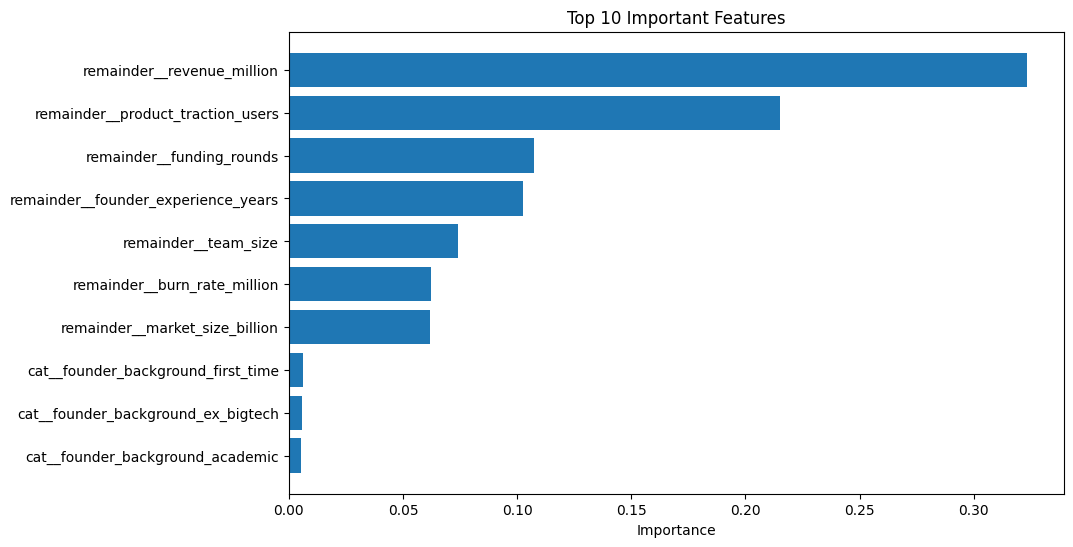

In [261]:
top10 = importance_df.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

In [262]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

In [263]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.76225
Precision: 0.7565650280024891
Recall   : 0.6847262897048885
F1 Score : 0.7188553183941346
ROC AUC  : 0.8378351881297351


In [264]:
scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print(scores)
print("Mean ROC-AUC:", scores.mean())

[0.8342386  0.83816002 0.83432799 0.83813991 0.83896535]
Mean ROC-AUC: 0.8367663739996619


In [265]:
joblib.dump(xgb_model, "../models/funding_model.pkl")

['../models/funding_model.pkl']

In [266]:
loaded_model = joblib.load("../models/funding_model.pkl")

In [ ]:
loaded_model.predict(X_test.iloc[[0]])
loaded_model.predict_proba(X_test.iloc[[0]])

array([[0.9432048 , 0.05679516]], dtype=float32)

In [268]:
df["sector"].unique()
df["founder_background"].unique()

array(['academic', 'first_time', 'ex_bigtech', 'serial_founder'],
      dtype=object)